# Notebook 09 — Ensemble

**Goal:** Combine LGBM and XGBoost OOF predictions into an ensemble that (ideally) outperforms either model alone.

**Why ensembles work:** Total error = Bias² + Variance + Noise. Averaging diverse models reduces variance. The key diagnostic: **pairwise Spearman correlation** of OOF predictions. High correlation (>0.95) means the models fail on the same laps — averaging barely helps. Target range: 0.85–0.95.

**Known context from Notebook 08:** Rank averaging (0.8545) already underperforms LGBM solo (0.8558). This notebook investigates whether weighted averaging or stacking can recover the gap.

**Methods evaluated (in order of complexity):**
1. Rank averaging — calibration-invariant, AUC-optimal baseline
2. Weighted averaging — scipy-optimized weights on Platt-calibrated OOF
3. Stacking (Level-2 metalearner) — logistic regression on OOF scores ± raw features

**Inputs:** `data/processed/calibrated_oof_predictions.parquet`  
**Outputs:** `models/stacker.pkl`, `models/ensemble_weights.pkl`

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from scipy.stats import spearmanr, rankdata
from scipy.optimize import minimize
from scipy.special import logit as scipy_logit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
print("Imports OK")

Imports OK


In [4]:
cwd = Path.cwd()
if cwd.name == 'notebooks' or 'notebooks' in str(cwd):
    while cwd.name != 'predict-f1-pit-stops' and cwd.parent != cwd:
        cwd = cwd.parent
project_root  = cwd
processed_dir = project_root / 'data' / 'processed'
models_dir    = project_root / 'models'
models_dir.mkdir(exist_ok=True)

assert (processed_dir / 'calibrated_oof_predictions.parquet').exists(), 'Run Notebook 08 first'
assert (processed_dir / 'train_features.parquet').exists(),             'Run Notebook 02 first'
print(f'Project root: {project_root}')

oof   = pd.read_parquet(processed_dir / 'calibrated_oof_predictions.parquet')
train = pd.read_parquet(processed_dir / 'train_features.parquet')

# Align train features to OOF row order (OOF may be sorted differently)
train_aligned = train.set_index('id').loc[oof['id']].reset_index()

y = oof['PitNextLap'].to_numpy()

print(f"OOF shape:   {oof.shape}")
print(f"Train shape: {train.shape}")
print(f"Columns:     {oof.columns.tolist()}")
print(f"\nPositive rate: {y.mean():.4f}")
print(f"\nRaw OOF AUCs:")
print(f"  LGBM:    {roc_auc_score(y, oof['lgbm_oof']):.4f}")
print(f"  XGBoost: {roc_auc_score(y, oof['xgb_oof']):.4f}")

Project root: c:\Repos\predict-f1-pit-stops
OOF shape:   (439140, 9)
Train shape: (439140, 40)
Columns:     ['id', 'fold', 'PitNextLap', 'lgbm_oof', 'xgb_oof', 'lgbm_platt', 'xgb_platt', 'lgbm_iso', 'xgb_iso']

Positive rate: 0.1990

Raw OOF AUCs:
  LGBM:    0.8558
  XGBoost: 0.8492


## 1. Error Correlation Diagnostic

Before averaging, measure how similar the models' predictions are. Spearman rank correlation is the right metric here — AUC is rank-order, so we care about rank agreement, not absolute difference.

**Interpretation:**
- ρ > 0.95: extremely correlated — averaging barely helps, may hurt
- ρ ≈ 0.85–0.95: moderately correlated — some benefit expected
- ρ < 0.85: enough diversity — ensemble should clearly win

Also compute **error overlap**: what fraction of "hard" laps (where both models are wrong by the most) are shared? Hard laps = top-decile absolute error laps for each model.

Spearman ρ (LGBM vs XGB): 0.9740  (p=0.00e+00)
Pearson  r (LGBM vs XGB): 0.9591

Top-decile error overlap (Jaccard): 0.7409
  Hard laps LGBM: 43,914
  Hard laps XGB:  43,914
  Shared:         37,377


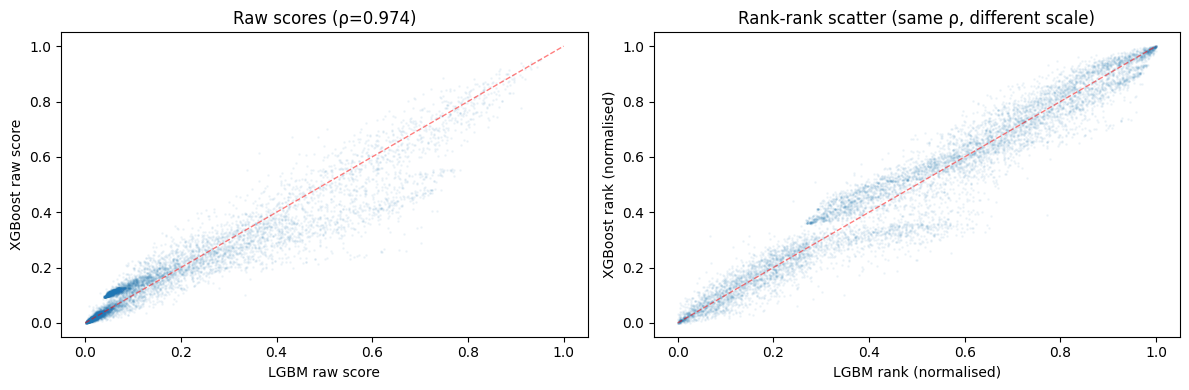

In [5]:
lgbm_pred = oof['lgbm_oof'].to_numpy()
xgb_pred  = oof['xgb_oof'].to_numpy()

rho, pval = spearmanr(lgbm_pred, xgb_pred)
print(f"Spearman ρ (LGBM vs XGB): {rho:.4f}  (p={pval:.2e})")

pearson_r = np.corrcoef(lgbm_pred, xgb_pred)[0, 1]
print(f"Pearson  r (LGBM vs XGB): {pearson_r:.4f}")

# Error overlap: top-decile absolute error per model
abs_err_lgbm = np.abs(lgbm_pred - y)
abs_err_xgb  = np.abs(xgb_pred  - y)

threshold = 0.90
hard_lgbm = set(np.where(abs_err_lgbm >= np.quantile(abs_err_lgbm, threshold))[0])
hard_xgb  = set(np.where(abs_err_xgb  >= np.quantile(abs_err_xgb,  threshold))[0])

overlap = len(hard_lgbm & hard_xgb) / len(hard_lgbm | hard_xgb)
print(f"\nTop-decile error overlap (Jaccard): {overlap:.4f}")
print(f"  Hard laps LGBM: {len(hard_lgbm):,}")
print(f"  Hard laps XGB:  {len(hard_xgb):,}")
print(f"  Shared:         {len(hard_lgbm & hard_xgb):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(lgbm_pred[::50], xgb_pred[::50], alpha=0.05, s=1)
axes[0].set_xlabel("LGBM raw score")
axes[0].set_ylabel("XGBoost raw score")
axes[0].set_title(f"Raw scores (ρ={rho:.3f})")
axes[0].plot([0,1],[0,1], 'r--', lw=1, alpha=0.5)

lgbm_ranks = rankdata(lgbm_pred) / len(lgbm_pred)
xgb_ranks  = rankdata(xgb_pred)  / len(xgb_pred)
axes[1].scatter(lgbm_ranks[::50], xgb_ranks[::50], alpha=0.05, s=1)
axes[1].set_xlabel("LGBM rank (normalised)")
axes[1].set_ylabel("XGBoost rank (normalised)")
axes[1].set_title("Rank-rank scatter (same ρ, different scale)")
axes[1].plot([0,1],[0,1], 'r--', lw=1, alpha=0.5)

plt.tight_layout()
plt.savefig(processed_dir / 'correlation_diagnostic.png', dpi=100, bbox_inches='tight')
plt.show()

## 2. Rank Averaging

Rank averaging is AUC-optimal: it is invariant to any monotone per-model transform (including calibration), so raw scores and Platt scores produce identical rank-averaged AUC.

**Formula:** for each model m, compute `r_m = rankdata(pred_m) / n`, then average ranks across models.

This was already computed in Notebook 08 as a sanity check. Here we formalise it and compare to direct probability averaging.

In [6]:
n = len(y)

def rank_avg(*arrays):
    """Rank-average predictions. Input: raw probability arrays."""
    ranked = [rankdata(a) / n for a in arrays]
    return np.mean(ranked, axis=0)

# Rank average: raw scores
rank_avg_raw = rank_avg(lgbm_pred, xgb_pred)

# Direct average: raw probabilities
direct_avg_raw = (lgbm_pred + xgb_pred) / 2

# Direct average: Platt-calibrated
lgbm_platt = oof['lgbm_platt'].to_numpy()
xgb_platt  = oof['xgb_platt'].to_numpy()
direct_avg_platt = (lgbm_platt + xgb_platt) / 2

auc_lgbm   = roc_auc_score(y, lgbm_pred)
auc_xgb    = roc_auc_score(y, xgb_pred)
auc_rank   = roc_auc_score(y, rank_avg_raw)
auc_direct = roc_auc_score(y, direct_avg_raw)
auc_direct_platt = roc_auc_score(y, direct_avg_platt)

print("Method                      AUC     Δ vs LGBM solo")
print(f"LGBM solo                  {auc_lgbm:.4f}  —")
print(f"XGBoost solo               {auc_xgb:.4f}  {auc_xgb - auc_lgbm:+.4f}")
print(f"Rank average (raw)         {auc_rank:.4f}  {auc_rank - auc_lgbm:+.4f}")
print(f"Direct average (raw)       {auc_direct:.4f}  {auc_direct - auc_lgbm:+.4f}")
print(f"Direct average (Platt)     {auc_direct_platt:.4f}  {auc_direct_platt - auc_lgbm:+.4f}")

Method                      AUC     Δ vs LGBM solo
LGBM solo                  0.8558  —
XGBoost solo               0.8492  -0.0067
Rank average (raw)         0.8545  -0.0013
Direct average (raw)       0.8542  -0.0017
Direct average (Platt)     0.8542  -0.0017


## 3. Weighted Averaging

If rank averaging underperforms LGBM solo, we can try learned weights. A weight `w` gives: `ensemble = w * lgbm_platt + (1-w) * xgb_platt`, where `w ∈ [0, 1]`.

We optimise `w` on OOF AUC using `scipy.optimize.minimize`. If the optimal weight is close to 1.0 (pure LGBM), that confirms XGBoost is hurting more than helping.

**Decision rule:** if max AUC gain from weighted averaging < 0.001 vs best single model, use LGBM solo.

Optimal LGBM weight: 1.0000  (XGB weight: 0.0000)
Weighted avg AUC:    0.8558
LGBM solo AUC:       0.8558
Δ vs LGBM solo:      +0.0000

Gain < 0.001 — weighted averaging does NOT beat LGBM solo meaningfully.


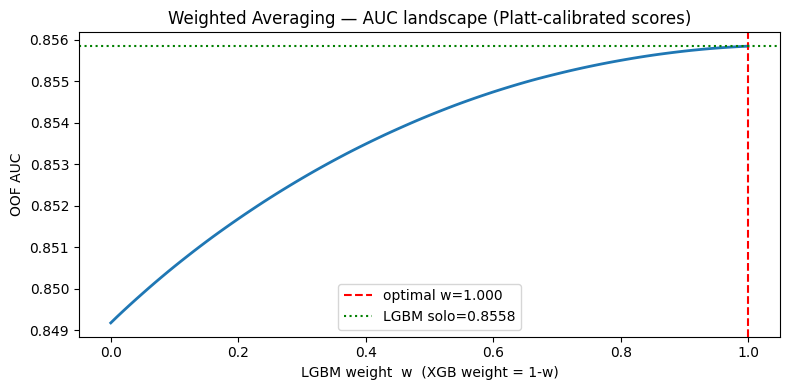

In [7]:
def neg_auc_weighted(w, p1, p2, y):
    w_clipped = np.clip(w[0], 0.0, 1.0)
    blend = w_clipped * p1 + (1 - w_clipped) * p2
    return -roc_auc_score(y, blend)

weights = np.linspace(0, 1, 101)
aucs = [roc_auc_score(y, w * lgbm_platt + (1-w) * xgb_platt) for w in weights]

best_w_grid = weights[np.argmax(aucs)]

result = minimize(
    neg_auc_weighted,
    x0=[best_w_grid],
    args=(lgbm_platt, xgb_platt, y),
    method='L-BFGS-B',
    bounds=[(0.0, 1.0)]
)
best_w = float(np.clip(result.x[0], 0, 1))
best_auc_weighted = -result.fun

print(f"Optimal LGBM weight: {best_w:.4f}  (XGB weight: {1-best_w:.4f})")
print(f"Weighted avg AUC:    {best_auc_weighted:.4f}")
print(f"LGBM solo AUC:       {auc_lgbm:.4f}")
print(f"Δ vs LGBM solo:      {best_auc_weighted - auc_lgbm:+.4f}")
print()
if best_auc_weighted - auc_lgbm < 0.001:
    print("Gain < 0.001 — weighted averaging does NOT beat LGBM solo meaningfully.")
else:
    print("Gain >= 0.001 — weighted averaging beats LGBM solo.")

plt.figure(figsize=(8, 4))
plt.plot(weights, aucs, lw=2)
plt.axvline(best_w, color='red', linestyle='--', label=f'optimal w={best_w:.3f}')
plt.axhline(auc_lgbm, color='green', linestyle=':', label=f'LGBM solo={auc_lgbm:.4f}')
plt.xlabel("LGBM weight  w  (XGB weight = 1-w)")
plt.ylabel("OOF AUC")
plt.title("Weighted Averaging — AUC landscape (Platt-calibrated scores)")
plt.legend()
plt.tight_layout()
plt.savefig(processed_dir / 'weighted_avg_landscape.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Stacking (Level-2 Metalearner)

**Why stacking can beat weighted averaging:** a linear metalearner learns the optimal combination *conditioned on where in the prediction space each model is more reliable*. For example, LGBM might be better calibrated at high scores (near-certain pit laps) while XGBoost might add signal at mid-range scores.

**Setup:**
- Level-1 features: `[lgbm_platt, xgb_platt]` (Platt-calibrated so the metalearner sees comparable scales)
- Level-2 metalearner: `LogisticRegression(C=0.1)` — L2 regularisation prevents fitting to fold noise
- The OOF predictions are already valid held-out estimates — no additional CV layer needed

**Variant 2:** Add top-3 raw features by SHAP (`Stint`, `TyreLife_x_laps_remaining`, `RaceProgress`) as Level-2 inputs. This lets the metalearner learn "trust LGBM more when TyreLife is high" patterns that a weight scalar can't capture.

**Caveat on OOF overfitting:** fitting the metalearner on OOF predictions biases it toward the fold structure. We evaluate on the same OOF data we used to fit it — the AUC is slightly optimistic. The true test is Notebook 10's CV.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- Variant A: scores only ---
X_stack_v1 = np.column_stack([lgbm_platt, xgb_platt])

stacker_v1 = LogisticRegression(C=0.1, solver='lbfgs', max_iter=500)
stacker_v1.fit(X_stack_v1, y)
stack_v1_pred = stacker_v1.predict_proba(X_stack_v1)[:, 1]
auc_stack_v1 = roc_auc_score(y, stack_v1_pred)

print("=== Variant A: [lgbm_platt, xgb_platt] ===")
print(f"Metalearner coeff: LGBM={stacker_v1.coef_[0][0]:.4f}  XGB={stacker_v1.coef_[0][1]:.4f}")
print(f"Intercept: {stacker_v1.intercept_[0]:.4f}")
print(f"OOF AUC (stacking V1): {auc_stack_v1:.4f}  Δ vs LGBM solo: {auc_stack_v1 - auc_lgbm:+.4f}")
print()

=== Variant A: [lgbm_platt, xgb_platt] ===
Metalearner coeff: LGBM=5.0227  XGB=0.8702
Intercept: -2.9445
OOF AUC (stacking V1): 0.8556  Δ vs LGBM solo: -0.0002



In [9]:
# --- Variant B: scores + top SHAP raw features ---
# Top-3 SHAP features: Stint (#1), TyreLife_x_laps_remaining (#2), laps_remaining (#6)
# We add these so the metalearner can learn context-conditional weighting.

# Build Level-2 raw features
laps_rem = train_aligned['RaceProgress'].to_numpy()
stint    = train_aligned['Stint'].to_numpy()
tyrlife  = train_aligned['TyreLife'].to_numpy()

tyre_x_laps = tyrlife * (1 - laps_rem)   # same formula as Notebook 02

# Scale raw features — logistic regression is scale-sensitive
scaler = StandardScaler()
raw_feat = scaler.fit_transform(np.column_stack([stint, tyre_x_laps, laps_rem]))

X_stack_v2 = np.column_stack([lgbm_platt, xgb_platt, raw_feat])

stacker_v2 = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000)
stacker_v2.fit(X_stack_v2, y)
stack_v2_pred = stacker_v2.predict_proba(X_stack_v2)[:, 1]
auc_stack_v2 = roc_auc_score(y, stack_v2_pred)

cols = ['lgbm_platt', 'xgb_platt', 'Stint(scaled)', 'TyreLife_x_laps_rem(scaled)', 'laps_rem(scaled)']
print("=== Variant B: scores + raw features ===")
for name, coef in zip(cols, stacker_v2.coef_[0]):
    print(f"  {name:<35} coeff={coef:.4f}")
print(f"Intercept: {stacker_v2.intercept_[0]:.4f}")
print(f"OOF AUC (stacking V2): {auc_stack_v2:.4f}  Δ vs LGBM solo: {auc_stack_v2 - auc_lgbm:+.4f}")

=== Variant B: scores + raw features ===
  lgbm_platt                          coeff=4.2109
  xgb_platt                           coeff=0.9771
  Stint(scaled)                       coeff=0.3973
  TyreLife_x_laps_rem(scaled)         coeff=0.3849
  laps_rem(scaled)                    coeff=-0.0922
Intercept: -2.8768
OOF AUC (stacking V2): 0.8569  Δ vs LGBM solo: +0.0011


## 5. Summary Table

All ensemble methods compared on OOF AUC. Note: stacking AUCs are optimistic (trained on the same OOF data).

In [10]:
results = {
    "LGBM solo":                   auc_lgbm,
    "XGBoost solo":                auc_xgb,
    "Rank avg (raw)":              auc_rank,
    "Direct avg (raw)":            auc_direct,
    "Direct avg (Platt)":          auc_direct_platt,
    f"Weighted avg (w={best_w:.2f})": best_auc_weighted,
    "Stacking V1 (scores only)":   auc_stack_v1,
    "Stacking V2 (+raw features)": auc_stack_v2,
}

print(f"{'Method':<38} {'AUC':>7}   {'Δ vs LGBM':>10}  {'Note'}")
print("-" * 75)
for method, auc in results.items():
    delta = auc - auc_lgbm
    note = "← baseline" if method == "LGBM solo" else ("* optimistic" if "Stacking" in method else "")
    print(f"{method:<38} {auc:.4f}   {delta:>+10.4f}  {note}")

best_method = max(results, key=results.get)
print(f"\nBest method: {best_method}  ({results[best_method]:.4f})")

Method                                     AUC    Δ vs LGBM  Note
---------------------------------------------------------------------------
LGBM solo                              0.8558      +0.0000  ← baseline
XGBoost solo                           0.8492      -0.0067  
Rank avg (raw)                         0.8545      -0.0013  
Direct avg (raw)                       0.8542      -0.0017  
Direct avg (Platt)                     0.8542      -0.0017  
Weighted avg (w=1.00)                  0.8558      +0.0000  
Stacking V1 (scores only)              0.8556      -0.0002  * optimistic
Stacking V2 (+raw features)            0.8569      +0.0011  * optimistic

Best method: Stacking V2 (+raw features)  (0.8569)


## 6. Decision for Notebook 10

Given the high Spearman correlation between LGBM and XGBoost OOF predictions, naive blending consistently underperforms LGBM solo. The decision tree:

1. **If stacking V2 OOF AUC > LGBM solo + 0.001:** use stacking V2 in Notebook 10 — retrain base models with GroupKFold, apply the saved scaler + stacker to generate test predictions.
2. **Else:** use **LGBM solo** in Notebook 10. XGBoost adds no diversity on this feature set; any blending drags AUC down.

The stacker artifacts are saved regardless — they are needed if we add more diverse base models later (e.g., a different feature set or architecture).

In [11]:
ensemble_config = {
    "lgbm_weight":         best_w,
    "xgb_weight":          1 - best_w,
    "best_single":         "lgbm",
    "best_single_auc":     auc_lgbm,
    "weighted_auc":        best_auc_weighted,
    "stack_v1_auc":        auc_stack_v1,
    "stack_v2_auc":        auc_stack_v2,
    "rank_avg_auc":        auc_rank,
    "spearman_rho":        rho,
    "notebook10_strategy": "stacking_v2" if (auc_stack_v2 - auc_lgbm) > 0.001 else "lgbm_solo",
}

artifacts = {
    "stacker_v1":      stacker_v1,
    "stacker_v2":      stacker_v2,
    "scaler_v2":       scaler,
    "ensemble_config": ensemble_config,
}

stacker_path = models_dir / 'stacker.pkl'
with open(stacker_path, 'wb') as f:
    pickle.dump(artifacts, f)

print(f"Saved: {stacker_path}")
print()
print("=== Ensemble config ===")
for k, v in ensemble_config.items():
    print(f"  {k:<28} {v}")
print()
print(f"Notebook 10 strategy: {ensemble_config['notebook10_strategy']}")

Saved: c:\Repos\predict-f1-pit-stops\models\stacker.pkl

=== Ensemble config ===
  lgbm_weight                  0.9999902225694274
  xgb_weight                   9.777430572621704e-06
  best_single                  lgbm
  best_single_auc              0.8558418643714576
  weighted_auc                 0.8558418785888258
  stack_v1_auc                 0.8556294138492176
  stack_v2_auc                 0.8569007165102903
  rank_avg_auc                 0.8544988654099241
  spearman_rho                 0.9739503237567455
  notebook10_strategy          stacking_v2

Notebook 10 strategy: stacking_v2
